# NB12 — Affect × Survival: Does computational threat drive subjective anxiety and confidence?

**Core question for the paper:** The FET model computes a survival probability S = exp(−p_threat × D^z).
Does this same computational signal govern *subjective affect* — anxiety and confidence ratings?
If so, the model explains behavior AND internal experience, not just choices.

**Design:**  
- ~18 anxiety ratings + ~18 confidence ratings per subject (0–7 scale), collected during foraging  
- Each rating has: threat probability (0.1/0.5/0.9), distance from safety (4/5/7/9)
- We compute a trial-level survival proxy: `S_probe = exp(−p_threat × D^z_i)` using fitted z_i  
- LMM: rating ~ S_probe + (1|subj)  
- Key moderation: `rating ~ p_threat × z_i_z + distance_z + (1|subj)` — do high-z subjects show stronger affect responses to threat?

**Predictions:**  
- Anxiety ↑ with threat (positive β for p_threat)  
- Confidence ↓ with threat (negative β for p_threat)  
- High-z subjects show stronger anxiety response to threat (positive interaction)  
- S_probe (lower = more dangerous) → anxiety ↑, confidence ↓

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
from pathlib import Path

BASE      = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
DATA      = BASE / 'data/exploratory_350/processed/stage5_filtered_data_20260317_094210'
STATS_DIR = BASE / 'results/stats'
FIG_DIR   = BASE / 'results/figures/affect'
FIG_DIR.mkdir(parents=True, exist_ok=True)

THREAT_COLORS = {0.1: '#2196F3', 0.5: '#FF9800', 0.9: '#F44336'}
RATING_MAX    = 7  # 0–7 scale

print('Libraries loaded.')

Libraries loaded.


## 1. Load and prepare data

In [2]:
# ── Feelings ratings ──────────────────────────────────────────────────────────
feel = pd.read_csv(DATA / 'feelings.csv')

# Rename for clarity
feel = feel.rename(columns={
    'attackingProb':      'p_threat',
    'questionLabel':      'affect_type',
    'response':           'rating',
    'trialNumber':        'trial_raw',
    'distanceFromSafety': 'dist_safety',
    'distance':           'dist_level',   # 0/1/2 → distance_H = dist_level + 1
})

# Distance_H: maps to the model's D parameter (1/2/3)
feel['D'] = feel['dist_level'] + 1

print(f'Feelings: {len(feel):,} rows, {feel["subj"].nunique()} subjects')
print(f'Affect types: {feel["affect_type"].value_counts().to_dict()}')
print(f'Rating range: {feel["rating"].min()}–{feel["rating"].max()}')
print(f'p_threat levels: {sorted(feel["p_threat"].unique())}')
print(f'D levels: {sorted(feel["D"].unique())}')

# ── Model parameters ─────────────────────────────────────────────────────────
z_df    = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_z_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'z'})
k_df    = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_k_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'kappa'})
beta_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_beta_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'beta_param'})
params  = z_df.merge(k_df, on='subj').merge(beta_df, on='subj')
print(f'\nParameters: {len(params)} subjects')

# Merge params into feelings
feel = feel.merge(params, on='subj', how='inner')
print(f'After merge: {len(feel):,} rows, {feel["subj"].nunique()} subjects')

# ── Compute trial-level survival proxy ───────────────────────────────────────
# S_probe = exp(−p_threat × D^z_i)
# Uses the FET model formula with subject's fitted z
feel['S_probe'] = np.exp(-feel['p_threat'] * feel['D'] ** feel['z'])

# Z-score predictors for LMM (so β coefficients are in SD units)
for col in ['p_threat', 'dist_safety', 'S_probe', 'z', 'kappa', 'beta_param']:
    feel[f'{col}_z'] = (feel[col] - feel[col].mean()) / feel[col].std()

print(f'\nS_probe range: {feel["S_probe"].min():.3f}–{feel["S_probe"].max():.3f}')
print('S_probe by threat × D:')
print(feel.groupby(['p_threat','D'])['S_probe'].mean().round(3).to_string())

Feelings: 10,546 rows, 293 subjects
Affect types: {'anxiety': 5274, 'confidence': 5272}
Rating range: 0–7
p_threat levels: [np.float64(0.1000000014901161), np.float64(0.5), np.float64(0.8999999761581421)]
D levels: [np.int64(1), np.int64(2), np.int64(3)]

Parameters: 293 subjects
After merge: 10,546 rows, 293 subjects

S_probe range: 0.011–0.905
S_probe by threat × D:
p_threat  D
0.1       1    0.905
          2    0.877
          3    0.856
0.5       1    0.607
          2    0.521
          3    0.469
0.9       1    0.407
          2    0.312
          3    0.262


## 2. Descriptive: how does affect vary with threat and distance?

Anxiety ratings by threat level:
           mean    sem  count
p_threat                     
0.1       3.719  0.054   1758
0.5       4.345  0.049   1758
0.9       5.134  0.052   1758

Confidence ratings by threat level:
           mean    sem  count
p_threat                     
0.1       3.905  0.053   1757
0.5       3.105  0.049   1757
0.9       2.487  0.056   1758

Anxiety ratings by D (distance):
    mean    sem
D              
1  4.112  0.052
2  4.415  0.052
3  4.671  0.055

Confidence ratings by D (distance):
    mean    sem
D              
1  3.536  0.052
2  3.142  0.053
3  2.819  0.056


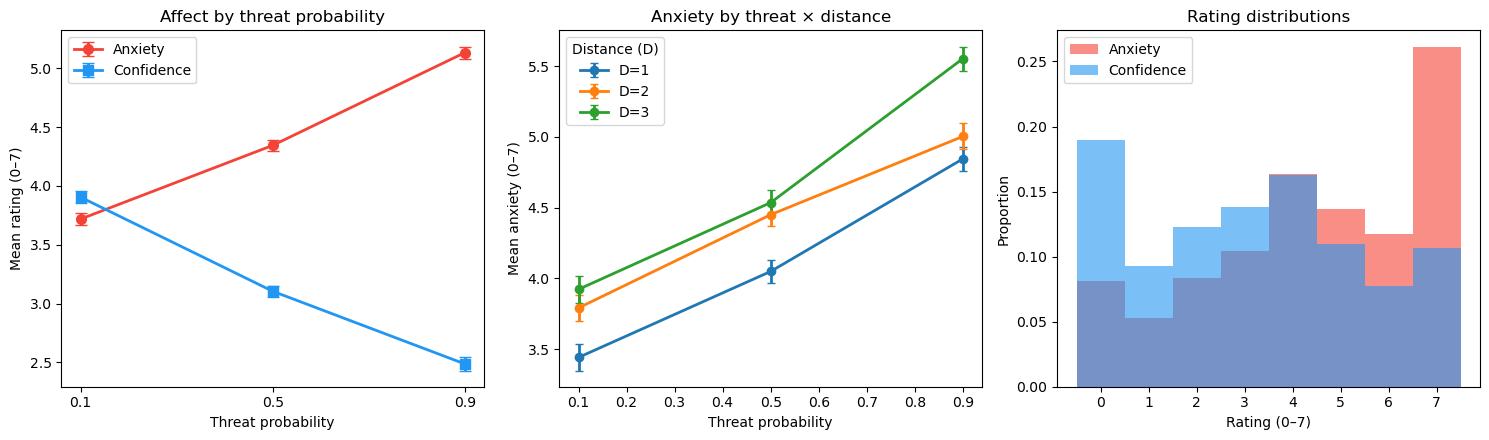

In [3]:
anx  = feel[feel['affect_type'] == 'anxiety'].copy()
conf = feel[feel['affect_type'] == 'confidence'].copy()

print('Anxiety ratings by threat level:')
print(anx.groupby('p_threat')['rating'].agg(['mean','sem','count']).round(3))
print()
print('Confidence ratings by threat level:')
print(conf.groupby('p_threat')['rating'].agg(['mean','sem','count']).round(3))
print()
print('Anxiety ratings by D (distance):')
print(anx.groupby('D')['rating'].agg(['mean','sem']).round(3))
print()
print('Confidence ratings by D (distance):')
print(conf.groupby('D')['rating'].agg(['mean','sem']).round(3))

# ── Plot: mean rating by threat level ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: anxiety and confidence means by threat level
ax = axes[0]
for label, df, color, marker in [('Anxiety', anx, '#F44336', 'o'), ('Confidence', conf, '#2196F3', 's')]:
    means = df.groupby('p_threat')['rating'].mean()
    sems  = df.groupby('p_threat')['rating'].sem()
    ax.errorbar(means.index, means.values, yerr=sems.values,
                color=color, marker=marker, linewidth=2, markersize=7,
                capsize=4, label=label)
ax.set_xlabel('Threat probability')
ax.set_ylabel('Mean rating (0–7)')
ax.set_title('Affect by threat probability')
ax.set_xticks([0.1, 0.5, 0.9])
ax.legend()

# Middle: anxiety by threat × distance
ax = axes[1]
for D_val, grp in anx.groupby('D'):
    means = grp.groupby('p_threat')['rating'].mean()
    sems  = grp.groupby('p_threat')['rating'].sem()
    ax.errorbar(means.index, means.values, yerr=sems.values,
                label=f'D={D_val}', linewidth=2, markersize=6, marker='o', capsize=3)
ax.set_xlabel('Threat probability')
ax.set_ylabel('Mean anxiety (0–7)')
ax.set_title('Anxiety by threat × distance')
ax.legend(title='Distance (D)')

# Right: rating distributions
ax = axes[2]
bins = np.arange(-0.5, 8.5, 1)
ax.hist(anx['rating'], bins=bins, alpha=0.6, color='#F44336', label='Anxiety', density=True)
ax.hist(conf['rating'], bins=bins, alpha=0.6, color='#2196F3', label='Confidence', density=True)
ax.set_xlabel('Rating (0–7)')
ax.set_ylabel('Proportion')
ax.set_title('Rating distributions')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'A_affect_by_threat.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LMM Analysis

**Model 1 (main effects):** `rating ~ p_threat_z + dist_safety_z + (1|subj)`  
Tests whether threat and distance modulate affect at the group level.

**Model 2 (S_probe):** `rating ~ S_probe_z + (1|subj)`  
Tests whether the model-derived survival probability drives affect (composite threat × distance × z signal).

**Model 3 (moderation):** `rating ~ p_threat_z * z_z + dist_safety_z + (1|subj)`  
Tests whether individual z moderates the threat→affect relationship.

In [4]:
def run_lmm(df, formula, groups='subj', label=''):
    """Fit LMM and return tidy results."""
    data = df.dropna(subset=[c for c in df.columns if c in formula]).reset_index(drop=True)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = smf.mixedlm(formula, data=data, groups=data[groups])
        result = model.fit(reml=False, method='lbfgs')

    tidy = pd.DataFrame({
        'term':   result.params.index,
        'beta':   result.params.values,
        'se':     result.bse.values,
        'z_stat': result.tvalues.values,
        'p':      result.pvalues.values,
    })
    tidy['affect'] = label
    tidy['aic']    = result.aic
    return tidy, result

# ── Run models ────────────────────────────────────────────────────────────────
results = []
sep = '=' * 60

for affect_label, df in [('anxiety', anx), ('confidence', conf)]:
    print(f'\n{sep}')
    print(f'  {affect_label.upper()}')
    print(sep)

    # Model 1: main effects
    tidy1, fit1 = run_lmm(df, 'rating ~ p_threat_z + dist_safety_z', label=affect_label)
    tidy1['model'] = 'main_effects'

    # Model 2: S_probe (composite model-derived predictor)
    tidy2, fit2 = run_lmm(df, 'rating ~ S_probe_z', label=affect_label)
    tidy2['model'] = 'S_probe'

    # Model 3: moderation by z
    tidy3, fit3 = run_lmm(df, 'rating ~ p_threat_z * z_z + dist_safety_z', label=affect_label)
    tidy3['model'] = 'moderation'

    results.extend([tidy1, tidy2, tidy3])

    # Print key results
    print('\nModel 1 — Main effects:')
    for _, row in tidy1[~tidy1['term'].isin(['Intercept','Group Var'])].iterrows():
        print(f"  {row['term']:30s} beta={row['beta']:+.3f} (SE={row['se']:.3f}), z={row['z_stat']:+.2f}, p={row['p']:.4f}")

    print('\nModel 2 — S_probe (composite):')
    for _, row in tidy2[~tidy2['term'].isin(['Intercept','Group Var'])].iterrows():
        print(f"  {row['term']:30s} beta={row['beta']:+.3f} (SE={row['se']:.3f}), z={row['z_stat']:+.2f}, p={row['p']:.4f}")

    print('\nModel 3 — Moderation by z:')
    for _, row in tidy3[~tidy3['term'].isin(['Intercept','Group Var'])].iterrows():
        print(f"  {row['term']:30s} beta={row['beta']:+.3f} (SE={row['se']:.3f}), z={row['z_stat']:+.2f}, p={row['p']:.4f}")

results_df = pd.concat(results, ignore_index=True)


  ANXIETY



Model 1 — Main effects:
  p_threat_z                     beta=+0.575 (SE=0.024), z=+23.77, p=0.0000
  dist_safety_z                  beta=+0.226 (SE=0.024), z=+9.44, p=0.0000

Model 2 — S_probe (composite):
  S_probe_z                      beta=-0.602 (SE=0.025), z=-24.51, p=0.0000

Model 3 — Moderation by z:
  p_threat_z                     beta=+0.575 (SE=0.024), z=+23.77, p=0.0000
  z_z                            beta=-0.088 (SE=0.076), z=-1.15, p=0.2484
  p_threat_z:z_z                 beta=-0.041 (SE=0.024), z=-1.69, p=0.0915
  dist_safety_z                  beta=+0.226 (SE=0.024), z=+9.45, p=0.0000

  CONFIDENCE



Model 1 — Main effects:
  p_threat_z                     beta=-0.586 (SE=0.024), z=-23.99, p=0.0000
  dist_safety_z                  beta=-0.283 (SE=0.025), z=-11.46, p=0.0000

Model 2 — S_probe (composite):
  S_probe_z                      beta=+0.632 (SE=0.025), z=+25.52, p=0.0000

Model 3 — Moderation by z:
  p_threat_z                     beta=-0.586 (SE=0.024), z=-23.99, p=0.0000
  z_z                            beta=-0.199 (SE=0.078), z=-2.56, p=0.0105
  p_threat_z:z_z                 beta=+0.016 (SE=0.024), z=+0.64, p=0.5204
  dist_safety_z                  beta=-0.283 (SE=0.025), z=-11.46, p=0.0000


In [5]:
# ── FDR correction across all tests (excluding intercepts and variance terms) ─
key_terms = results_df[~results_df['term'].isin(['Intercept', 'Group Var'])].copy()
_, p_fdr, _, _ = multipletests(key_terms['p'], method='fdr_bh')
key_terms['p_fdr'] = p_fdr
key_terms['sig']   = key_terms['p_fdr'] < 0.05

print('Key results (FDR-corrected):')
print('=' * 75)
for _, row in key_terms.sort_values(['affect','model','p']).iterrows():
    sig_str = ' ***' if row['p_fdr'] < 0.001 else (' **' if row['p_fdr'] < 0.01 else (' *' if row['p_fdr'] < 0.05 else ' n.s.'))
    print(f"  [{row['affect']:10s}][{row['model']:12s}] {row['term']:28s} β={row['beta']:+.3f}, p_fdr={row['p_fdr']:.4f}{sig_str}")

Key results (FDR-corrected):
  [anxiety   ][S_probe     ] S_probe_z                    β=-0.602, p_fdr=0.0000 ***
  [anxiety   ][main_effects] p_threat_z                   β=+0.575, p_fdr=0.0000 ***
  [anxiety   ][main_effects] dist_safety_z                β=+0.226, p_fdr=0.0000 ***
  [anxiety   ][moderation  ] p_threat_z                   β=+0.575, p_fdr=0.0000 ***
  [anxiety   ][moderation  ] dist_safety_z                β=+0.226, p_fdr=0.0000 ***
  [anxiety   ][moderation  ] p_threat_z:z_z               β=-0.041, p_fdr=0.1067 n.s.
  [anxiety   ][moderation  ] z_z                          β=-0.088, p_fdr=0.2675 n.s.
  [confidence][S_probe     ] S_probe_z                    β=+0.632, p_fdr=0.0000 ***
  [confidence][main_effects] p_threat_z                   β=-0.586, p_fdr=0.0000 ***
  [confidence][main_effects] dist_safety_z                β=-0.283, p_fdr=0.0000 ***
  [confidence][moderation  ] p_threat_z                   β=-0.586, p_fdr=0.0000 ***
  [confidence][moderation  ] dist_

## 4. Visualise moderation: z moderates threat → affect

Split subjects into low/high z tertiles; plot threat → anxiety separately for each group.

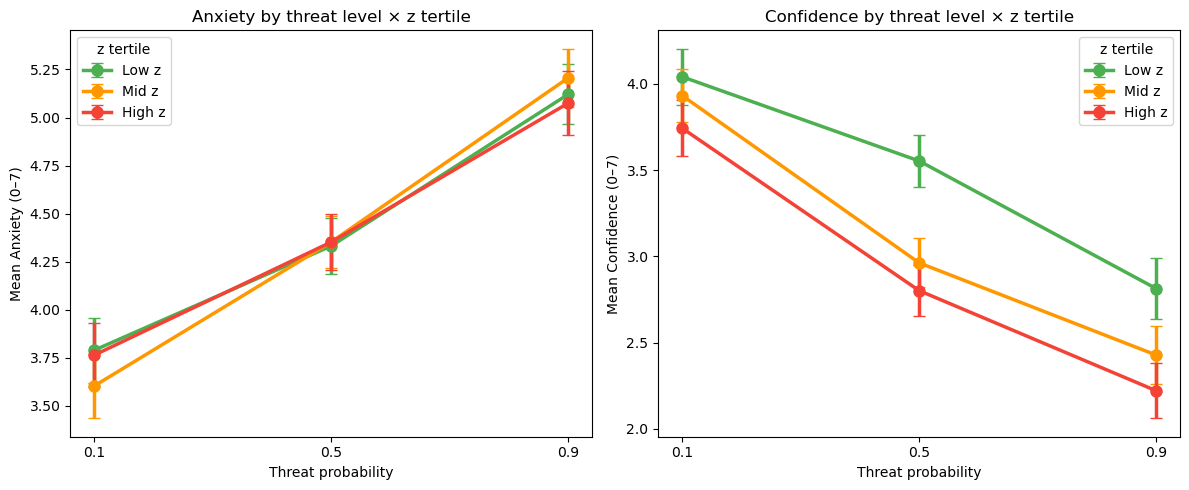

Mean anxiety by threat × z tertile:
z_group  p_threat
Low z    0.1         3.79
         0.5         4.33
         0.9         5.12
Mid z    0.1         3.60
         0.5         4.35
         0.9         5.21
High z   0.1         3.76
         0.5         4.35
         0.9         5.07


In [6]:
# Subject-level means of z and affect by threat level
z_tertiles = params.copy()
z_tertiles['z_group'] = pd.qcut(z_tertiles['z'], q=3, labels=['Low z', 'Mid z', 'High z'])

feel_z = feel.merge(z_tertiles[['subj','z_group']], on='subj', how='left')
anx_z  = feel_z[feel_z['affect_type'] == 'anxiety']
conf_z = feel_z[feel_z['affect_type'] == 'confidence']

z_colors = {'Low z': '#4CAF50', 'Mid z': '#FF9800', 'High z': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (affect_label, df) in zip(axes, [('Anxiety', anx_z), ('Confidence', conf_z)]):
    # Subject-level means per threat level
    subj_means = df.groupby(['subj', 'p_threat', 'z_group'])['rating'].mean().reset_index()

    for z_grp, grp in subj_means.groupby('z_group', observed=True):
        group_mean = grp.groupby('p_threat')['rating'].mean()
        group_sem  = grp.groupby('p_threat')['rating'].sem()
        ax.errorbar(group_mean.index, group_mean.values, yerr=group_sem.values,
                    color=z_colors[str(z_grp)], label=str(z_grp),
                    linewidth=2.5, markersize=8, marker='o', capsize=4)

    ax.set_xlabel('Threat probability')
    ax.set_ylabel(f'Mean {affect_label} (0–7)')
    ax.set_title(f'{affect_label} by threat level × z tertile')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.legend(title='z tertile')

plt.tight_layout()
plt.savefig(FIG_DIR / 'B_moderation_by_z.png', dpi=150, bbox_inches='tight')
plt.show()

# Print subject-level threat sensitivity per z tertile
print('Mean anxiety by threat × z tertile:')
print(anx_z.groupby(['z_group','p_threat'], observed=True)['rating'].mean().round(2).to_string())

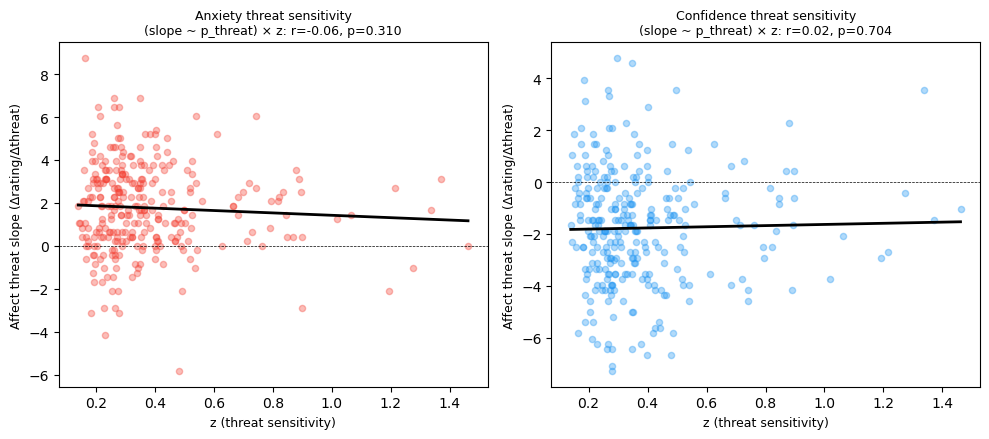

anxiety threat slope ~ z: r=-0.060, p=0.3097
confidence threat slope ~ z: r=0.022, p=0.7039


In [7]:
# ── Subject-level threat sensitivity as a function of z ─────────────────────
# Per subject: slope of mean_anxiety ~ p_threat (same logic as tonic_threat_slope in NB11)
def affect_threat_slope(df):
    means = df.groupby('p_threat')['rating'].mean()
    if len(means) < 2:
        return np.nan
    x = np.array(means.index.astype(float))
    y = np.array(means.values)
    return np.polyfit(x, y, 1)[0]

anx_slope = (
    anx.groupby('subj')
    .apply(affect_threat_slope)
    .reset_index()
    .rename(columns={0: 'anx_threat_slope'})
)
conf_slope = (
    conf.groupby('subj')
    .apply(affect_threat_slope)
    .reset_index()
    .rename(columns={0: 'conf_threat_slope'})
)

subj_affect = params.merge(anx_slope, on='subj').merge(conf_slope, on='subj')

# Correlate threat sensitivity in affect with z
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, (feat, label, color) in zip(axes, [
    ('anx_threat_slope',  'Anxiety threat sensitivity',    '#F44336'),
    ('conf_threat_slope', 'Confidence threat sensitivity', '#2196F3'),
]):
    x = subj_affect['z'].values
    y = subj_affect[feat].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    ax.scatter(x, y, alpha=0.35, s=20, color=color)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k-', lw=2)
    ax.axhline(0, color='k', lw=0.5, ls='--')

    r, p = stats.pearsonr(x, y)
    ax.set_title(f'{label}\n(slope ~ p_threat) × z: r={r:.2f}, p={p:.3f}', fontsize=9)
    ax.set_xlabel('z (threat sensitivity)', fontsize=9)
    ax.set_ylabel('Affect threat slope (Δrating/Δthreat)', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'C_affect_slope_vs_z.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlations
for feat, label in [('anx_threat_slope', 'anxiety'), ('conf_threat_slope', 'confidence')]:
    r, p = stats.pearsonr(subj_affect['z'], subj_affect[feat])
    print(f'{label} threat slope ~ z: r={r:.3f}, p={p:.4f}')

## 5. S_probe as unified predictor

S_probe = exp(−p_threat × D^z_i) integrates threat probability, distance, and individual sensitivity into a single survival probability. Test whether this unified computational signal better predicts affect than its components separately.

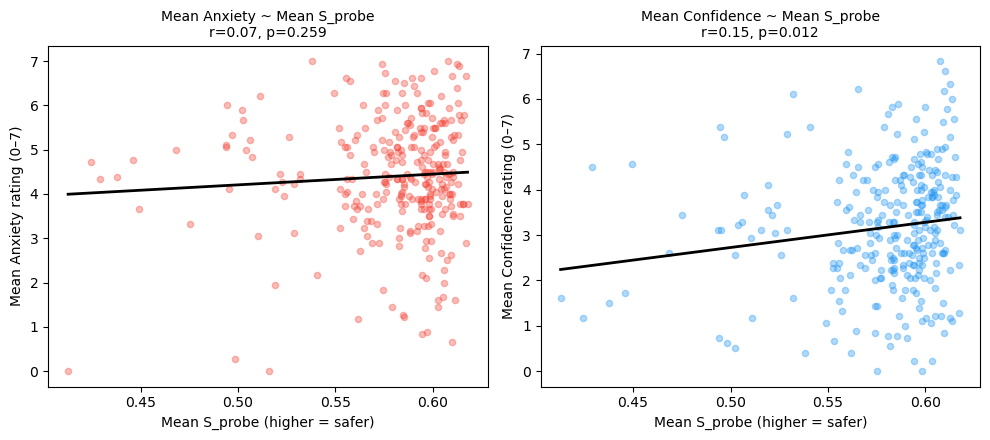

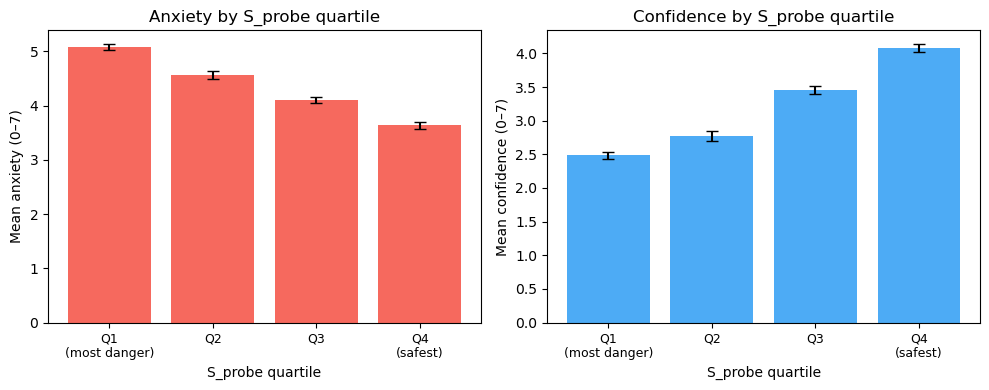

In [8]:
# Subject-level mean affect vs mean S_probe
subj_anx  = anx.groupby('subj').agg(mean_rating=('rating','mean'), mean_S=('S_probe','mean')).reset_index()
subj_conf = conf.groupby('subj').agg(mean_rating=('rating','mean'), mean_S=('S_probe','mean')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, (df_s, label, color) in zip(axes, [
    (subj_anx,  'Anxiety',    '#F44336'),
    (subj_conf, 'Confidence', '#2196F3'),
]):
    x = df_s['mean_S'].values
    y = df_s['mean_rating'].values
    ax.scatter(x, y, alpha=0.35, s=20, color=color)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k-', lw=2)
    r, p = stats.pearsonr(x, y)
    ax.set_title(f'Mean {label} ~ Mean S_probe\nr={r:.2f}, p={p:.3f}', fontsize=10)
    ax.set_xlabel('Mean S_probe (higher = safer)')
    ax.set_ylabel(f'Mean {label} rating (0–7)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'D_affect_vs_S_probe.png', dpi=150, bbox_inches='tight')
plt.show()

# S_probe bin analysis: split into quartiles, show mean affect per bin
feel['S_probe_bin'] = pd.qcut(feel['S_probe'], q=4, labels=['Q1\n(most danger)', 'Q2', 'Q3', 'Q4\n(safest)'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (af_type, color) in zip(axes, [('anxiety','#F44336'),('confidence','#2196F3')]):
    df_bin = feel[feel['affect_type']==af_type].groupby('S_probe_bin', observed=True)['rating'].agg(['mean','sem'])
    ax.bar(range(len(df_bin)), df_bin['mean'], yerr=df_bin['sem'], capsize=4, color=color, alpha=0.8)
    ax.set_xticks(range(len(df_bin)))
    ax.set_xticklabels(df_bin.index, fontsize=9)
    ax.set_xlabel('S_probe quartile')
    ax.set_ylabel(f'Mean {af_type} (0–7)')
    ax.set_title(f'{af_type.capitalize()} by S_probe quartile')
plt.tight_layout()
plt.savefig(FIG_DIR / 'E_affect_by_Sprobe_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save results

In [9]:
# Save LMM results
key_terms.to_csv(STATS_DIR / 'affect_lmm_results.csv', index=False)
print(f'Saved: {STATS_DIR / "affect_lmm_results.csv"}')

# Save subject-level affect slopes
subj_affect.to_csv(STATS_DIR / 'affect_threat_slopes.csv', index=False)
print(f'Saved: {STATS_DIR / "affect_threat_slopes.csv"}')

print()
print('=== KEY RESULTS ===')
print()
sig = key_terms[key_terms['sig']].sort_values('p_fdr')
if len(sig) == 0:
    print('No results survived FDR correction.')
else:
    for _, row in sig.iterrows():
        sig_str = '***' if row['p_fdr'] < 0.001 else ('**' if row['p_fdr'] < 0.01 else '*')
        print(f"  [{row['affect']:10s}][{row['model']:12s}] {row['term']:28s} β={row['beta']:+.3f}, p_fdr={row['p_fdr']:.4f} {sig_str}")

Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/affect_lmm_results.csv
Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/affect_threat_slopes.csv

=== KEY RESULTS ===

  [confidence][S_probe     ] S_probe_z                    β=+0.632, p_fdr=0.0000 ***
  [anxiety   ][S_probe     ] S_probe_z                    β=-0.602, p_fdr=0.0000 ***
  [confidence][main_effects] p_threat_z                   β=-0.586, p_fdr=0.0000 ***
  [confidence][moderation  ] p_threat_z                   β=-0.586, p_fdr=0.0000 ***
  [anxiety   ][main_effects] p_threat_z                   β=+0.575, p_fdr=0.0000 ***
  [anxiety   ][moderation  ] p_threat_z                   β=+0.575, p_fdr=0.0000 ***
  [confidence][main_effects] dist_safety_z                β=-0.283, p_fdr=0.0000 ***
  [confidence][moderation  ] dist_safety_z                β=-0.283, p_fdr=0.0000 ***
  [anxiety   ][main_effects] dist_safety_z                β=+0.226, p_fdr=0.0000 ***
  [anxiety   ][moderation  

## 7. State–Trait Decomposition

**Threat imminence theory predicts two separable components of affective response:**
- **Trait (tonic)**: chronic baseline defensive posture — set by stable individual differences in z, κ
- **State (phasic)**: momentary reactivity to encountered threat — driven by trial-level p_threat and distance

Decompose each subject's ratings into:
- `trait_i` = mean rating across all probe trials (between-subjects)
- `state_it` = rating − trait_i (within-subjects deviation)

Then test separately:
- Between: `trait ~ z + κ + β` (OLS) — which parameters set the baseline?
- Within: `state ~ p_threat_z + dist_safety_z + (1|subj)` (LMM) — what drives momentary fluctuation?

**Prediction**: z → trait anxiety/confidence; p_threat → state anxiety/confidence; crucially, z does NOT moderate state reactivity.

In [10]:
from scipy.stats import pearsonr
import statsmodels.api as sm

# ── Compute trait and state components ───────────────────────────────────────
for af_type, df_af in [('anxiety', anx), ('confidence', conf)]:
    feel.loc[feel['affect_type'] == af_type, 'trait'] = feel.loc[
        feel['affect_type'] == af_type
    ].groupby('subj')['rating'].transform('mean')

feel['state'] = feel['rating'] - feel['trait']
anx  = feel[feel['affect_type'] == 'anxiety'].copy()
conf = feel[feel['affect_type'] == 'confidence'].copy()

# Subject-level trait scores
trait_anx  = anx.groupby('subj')['trait'].first().reset_index().rename(columns={'trait': 'trait_anx'})
trait_conf = conf.groupby('subj')['trait'].first().reset_index().rename(columns={'trait': 'trait_conf'})
subj_trait = params.merge(trait_anx, on='subj').merge(trait_conf, on='subj')

print('Trait affect (subject-level means):')
print(f"  Anxiety  — mean={subj_trait['trait_anx'].mean():.2f}, SD={subj_trait['trait_anx'].std():.2f}, range=[{subj_trait['trait_anx'].min():.1f}, {subj_trait['trait_anx'].max():.1f}]")
print(f"  Confidence — mean={subj_trait['trait_conf'].mean():.2f}, SD={subj_trait['trait_conf'].std():.2f}, range=[{subj_trait['trait_conf'].min():.1f}, {subj_trait['trait_conf'].max():.1f}]")

# ── BETWEEN: OLS regression of trait ~ z + kappa + beta ──────────────────────
print('\n--- BETWEEN-SUBJECTS: Trait affect ~ z + kappa + beta ---')
trait_results = []
for dv, label in [('trait_anx', 'Trait Anxiety'), ('trait_conf', 'Trait Confidence')]:
    y = subj_trait[dv].values
    X = sm.add_constant(subj_trait[['z', 'kappa', 'beta_param']].values)
    fit = sm.OLS(y, X).fit()
    print(f'\n{label} (N={len(y)}):')
    for term, b, se, t, p in zip(
        ['intercept', 'z', 'kappa', 'beta'],
        fit.params, fit.bse, fit.tvalues, fit.pvalues
    ):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        print(f"  {term:12s}: beta={b:+.3f}, SE={se:.3f}, t={t:+.2f}, p={p:.4f} {sig}")
    print(f"  adj. R² = {fit.rsquared_adj:.3f}")
    trait_results.append({'dv': dv, 'label': label, 'adj_r2': fit.rsquared_adj,
                          'betas': dict(zip(['intercept','z','kappa','beta'], fit.params)),
                          'pvals': dict(zip(['intercept','z','kappa','beta'], fit.pvalues))})

# ── WITHIN: LMM of state ~ p_threat_z + dist_safety_z ───────────────────────
print('\n--- WITHIN-SUBJECTS: State affect ~ p_threat + distance ---')
for af_type, df_af, label in [('anxiety', anx, 'State Anxiety'), ('confidence', conf, 'State Confidence')]:
    tidy_s, _ = run_lmm(df_af, 'state ~ p_threat_z + dist_safety_z', label=af_type)
    print(f'\n{label}:')
    for _, row in tidy_s[~tidy_s['term'].isin(['Intercept','Group Var'])].iterrows():
        sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'n.s.'))
        print(f"  {row['term']:25s}: beta={row['beta']:+.3f}, SE={row['se']:.3f}, z={row['z_stat']:+.2f}, p={row['p']:.4f} {sig}")

# Recreate feel_z with state column for plots in next cell
feel_z = feel.merge(z_tertiles[['subj','z_group']], on='subj', how='left')


Trait affect (subject-level means):
  Anxiety  — mean=4.40, SD=1.31, range=[0.0, 7.0]
  Confidence — mean=3.17, SD=1.35, range=[0.0, 6.8]

--- BETWEEN-SUBJECTS: Trait affect ~ z + kappa + beta ---

Trait Anxiety (N=293):
  intercept   : beta=+4.269, SE=0.181, t=+23.54, p=0.0000 ***
  z           : beta=-0.581, SE=0.349, t=-1.66, p=0.0971 n.s.
  kappa       : beta=+0.146, SE=0.062, t=+2.36, p=0.0187 *
  beta        : beta=+0.045, SE=0.041, t=+1.11, p=0.2692 n.s.
  adj. R² = 0.020

Trait Confidence (N=293):
  intercept   : beta=+3.776, SE=0.185, t=+20.39, p=0.0000 ***
  z           : beta=-0.719, SE=0.356, t=-2.02, p=0.0445 *
  kappa       : beta=-0.163, SE=0.063, t=-2.59, p=0.0102 *
  beta        : beta=-0.015, SE=0.041, t=-0.37, p=0.7094 n.s.
  adj. R² = 0.036

--- WITHIN-SUBJECTS: State affect ~ p_threat + distance ---

State Anxiety:
  p_threat_z               : beta=+0.575, SE=0.024, z=+24.45, p=0.0000 ***
  dist_safety_z            : beta=+0.226, SE=0.023, z=+9.71, p=0.0000 ***

St

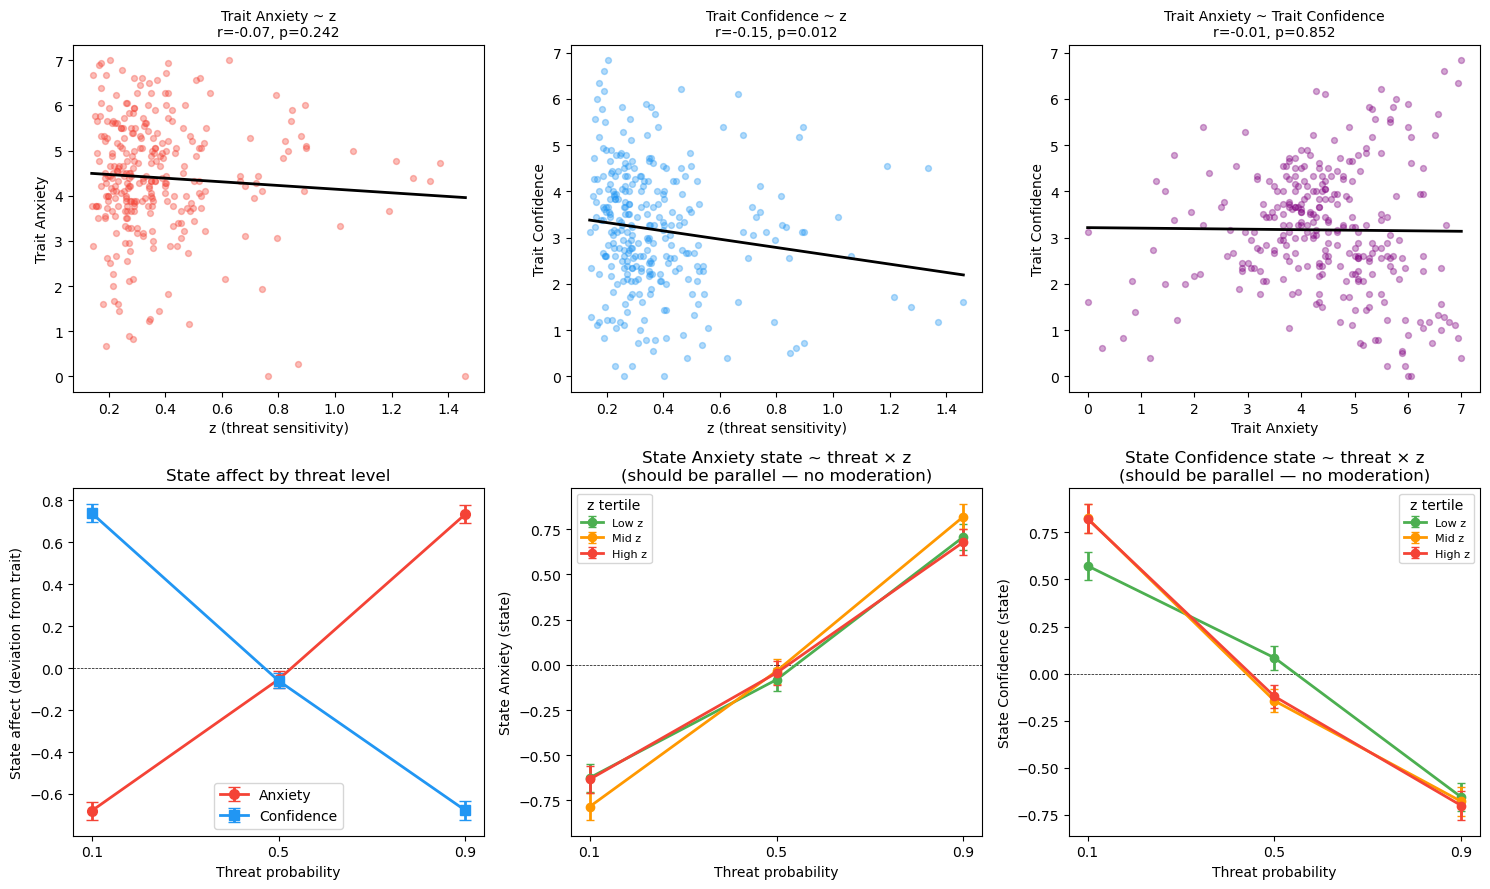

In [11]:
# ── Plot state-trait decomposition ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: trait affect ~ z
for col, (dv, af_label, color) in enumerate([
    ('trait_anx',  'Trait Anxiety',     '#F44336'),
    ('trait_conf', 'Trait Confidence',  '#2196F3'),
]):
    ax = axes[0, col]
    x = subj_trait['z'].values
    y = subj_trait[dv].values
    ax.scatter(x, y, alpha=0.35, s=18, color=color)
    m, b = np.polyfit(x, y, 1)
    ax.plot(np.linspace(x.min(), x.max(), 100), m * np.linspace(x.min(), x.max(), 100) + b, 'k-', lw=2)
    r, p = pearsonr(x, y)
    ax.set_title(f'{af_label} ~ z\nr={r:.2f}, p={p:.3f}', fontsize=10)
    ax.set_xlabel('z (threat sensitivity)')
    ax.set_ylabel(af_label)

# Top row col 2: trait anxiety ~ trait confidence (cross-domain trait correlation)
ax = axes[0, 2]
x = subj_trait['trait_anx'].values
y = subj_trait['trait_conf'].values
ax.scatter(x, y, alpha=0.35, s=18, color='purple')
m, b = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(), x.max(), 100), m * np.linspace(x.min(), x.max(), 100) + b, 'k-', lw=2)
r, p = pearsonr(x, y)
ax.set_title(f'Trait Anxiety ~ Trait Confidence\nr={r:.2f}, p={p:.3f}', fontsize=10)
ax.set_xlabel('Trait Anxiety')
ax.set_ylabel('Trait Confidence')

# Bottom row: state affect by threat level (group-level, to confirm within-subject effect)
ax = axes[1, 0]
for af_type, color, marker in [('anxiety','#F44336','o'), ('confidence','#2196F3','s')]:
    df_s = feel[feel['affect_type'] == af_type]
    means = df_s.groupby('p_threat')['state'].mean()
    sems  = df_s.groupby('p_threat')['state'].sem()
    ax.errorbar(means.index, means.values, yerr=sems.values,
                color=color, marker=marker, linewidth=2, markersize=7, capsize=4,
                label=af_type.capitalize())
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Threat probability')
ax.set_ylabel('State affect (deviation from trait)')
ax.set_title('State affect by threat level')
ax.set_xticks([0.1, 0.5, 0.9])
ax.legend()

# Bottom col 1-2: state modulation by z tertile
for col, (af_type, color, af_label) in enumerate([
    ('anxiety',    '#F44336', 'State Anxiety'),
    ('confidence', '#2196F3', 'State Confidence'),
], start=1):
    ax = axes[1, col]
    df_sz = feel_z[feel_z['affect_type'] == af_type]
    for z_grp, grp in df_sz.groupby('z_group', observed=True):
        means = grp.groupby('p_threat')['state'].mean()
        sems  = grp.groupby('p_threat')['state'].sem()
        ax.errorbar(means.index, means.values, yerr=sems.values,
                    color=z_colors[str(z_grp)], label=str(z_grp),
                    linewidth=2, markersize=6, marker='o', capsize=3)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('Threat probability')
    ax.set_ylabel(f'{af_label} (state)')
    ax.set_title(f'{af_label} state ~ threat × z\n(should be parallel — no moderation)')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.legend(title='z tertile', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'F_state_trait_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-domain reactive correlation: vigor × affect

**Threat imminence theory predicts two parallel dissociations across motor and affective domains:**

- **Deliberative system** (same z parameter drives both):
  - Vigor: `onset_threat_mod` — how much threat level modulates anticipatory pressing
  - Affect: `anx_threat_slope` — how much threat level modulates anxiety  
  - Prediction: *should correlate* (same z drives both)

- **Reactive system** (dissociated from deliberative parameters):
  - Vigor: `reactive_spike` — encounter-triggered motor surge (independent of z, κ, β)
  - Affect: `trait_anx` — chronic baseline anxiety (z → chronic confidence deficit, but what about baseline anxiety?)
  - Prediction: if reactive systems are coupled across domains, reactive_spike ~ trait_anx should correlate

The deliberative correlation would confirm a common computational substrate. The reactive correlation would reveal whether the reactive motor and affective systems share individual-difference variance.

In [12]:
# ── Load subject vigor table ──────────────────────────────────────────────────
svt = pd.read_csv(BASE / 'data/exploratory_350/processed/vigor_processed/subject_vigor_table.csv')

# Key vigor features (z-scored versions already in table)
vigor_features = {
    'tonic_vigor':              'Tonic vigor\n(baseline pressing)',
    'anticipatory_mobilization':'Anticipatory mobilization\n(onset threat modulation)',
    'reactive_spike':           'Reactive spike\n(encounter-triggered)',
    'terminal_persistence':     'Terminal persistence\n(pre-escape pressing)',
    'onset_threat_mod':         'Onset threat modulation\n(threat × anticipatory slope)',
}

# Merge with trait affect and params
cross = (
    svt[['subj'] + list(vigor_features.keys())]
    .merge(subj_trait[['subj','trait_anx','trait_conf']], on='subj')
    .merge(params, on='subj')
)

# Also merge anx_threat_slope from subj_affect
cross = cross.merge(subj_affect[['subj','anx_threat_slope','conf_threat_slope']], on='subj')

print(f'Cross-domain dataset: {len(cross)} subjects')

# ── Correlation matrix: vigor features × affect features ─────────────────────
affect_features = {
    'trait_anx':       'Trait Anxiety',
    'trait_conf':      'Trait Confidence',
    'anx_threat_slope':'Anxiety threat slope\n(state reactivity)',
}

cross_corr = []
for vf in vigor_features:
    for af in affect_features:
        x = cross[vf].values
        y = cross[af].values
        mask = np.isfinite(x) & np.isfinite(y)
        r, p = pearsonr(x[mask], y[mask])
        cross_corr.append({'vigor': vf, 'affect': af, 'r': r, 'p': p, 'n': mask.sum()})

cross_corr_df = pd.DataFrame(cross_corr)
_, p_fdr_cross, _, _ = multipletests(cross_corr_df['p'], method='fdr_bh')
cross_corr_df['p_fdr'] = p_fdr_cross
cross_corr_df['sig']   = cross_corr_df['p_fdr'] < 0.05

print('\nCross-domain correlations (vigor × affect):')
print('=' * 70)
for _, row in cross_corr_df.sort_values('p').iterrows():
    sig_str = ' ***' if row['p_fdr'] < 0.001 else (' **' if row['p_fdr'] < 0.01 else (' *' if row['p_fdr'] < 0.05 else ' n.s.'))
    print(f"  {row['vigor']:30s} ~ {row['affect']:22s}: r={row['r']:+.3f}, p_fdr={row['p_fdr']:.3f}{sig_str}")

Cross-domain dataset: 293 subjects

Cross-domain correlations (vigor × affect):
  tonic_vigor                    ~ anx_threat_slope      : r=+0.124, p_fdr=0.196 n.s.
  tonic_vigor                    ~ trait_anx             : r=-0.121, p_fdr=0.196 n.s.
  anticipatory_mobilization      ~ anx_threat_slope      : r=+0.121, p_fdr=0.196 n.s.
  terminal_persistence           ~ trait_conf            : r=-0.066, p_fdr=0.650 n.s.
  anticipatory_mobilization      ~ trait_conf            : r=-0.065, p_fdr=0.650 n.s.
  anticipatory_mobilization      ~ trait_anx             : r=-0.061, p_fdr=0.650 n.s.
  reactive_spike                 ~ anx_threat_slope      : r=-0.060, p_fdr=0.650 n.s.
  terminal_persistence           ~ trait_anx             : r=+0.037, p_fdr=0.865 n.s.
  terminal_persistence           ~ anx_threat_slope      : r=+0.035, p_fdr=0.865 n.s.
  onset_threat_mod               ~ trait_anx             : r=-0.032, p_fdr=0.865 n.s.
  onset_threat_mod               ~ trait_conf            : r

## 9. Moderation tests for draft claims

Two specific moderation hypotheses from the paper draft — not yet tested:

**Hypothesis A (Distance × z):** Higher hazard sensitivity (z) → steeper emotional response to *distance*.
`rating ~ dist_safety_z * z_z + p_threat_z + (1|subj)`

**Hypothesis B (Threat × β):** Higher threat bias (β) → amplified anxiety response to *threat intensity*.
`rating ~ p_threat_z * beta_z + dist_safety_z + (1|subj)`

These are distinct from the previously tested `p_threat × z` moderation (which was null).
Draft placeholder values: Distance × z anxiety p=.032, confidence p=.021; Threat × β anxiety p=.033.

In [13]:
# ── Moderation models for draft hypotheses ────────────────────────────────────
# Need beta_z in feel — merge if not present
if 'beta_param_z' not in feel.columns:
    feel = feel.merge(
        params[['subj','beta_param']].assign(
            beta_param_z=lambda d: (d['beta_param'] - d['beta_param'].mean()) / d['beta_param'].std()
        )[['subj','beta_param_z']],
        on='subj', how='left'
    )

anx  = feel[feel['affect_type'] == 'anxiety'].copy()
conf = feel[feel['affect_type'] == 'confidence'].copy()

draft_results = []
sep = '=' * 65

for affect_label, df in [('anxiety', anx), ('confidence', conf)]:
    print(f'\n{sep}')
    print(f'  {affect_label.upper()}')
    print(sep)

    # Hypothesis A: dist_safety × z
    tA, _ = run_lmm(df, 'rating ~ dist_safety_z * z_z + p_threat_z',
                    label=affect_label)
    tA['model'] = 'dist_x_z'
    print('\nHypothesis A — dist_safety × z:')
    for _, row in tA[~tA['term'].isin(['Intercept','Group Var'])].iterrows():
        sig = '***' if row['p']<0.001 else ('**' if row['p']<0.01 else ('*' if row['p']<0.05 else 'n.s.'))
        print(f"  {row['term']:30s} β={row['beta']:+.3f} (SE={row['se']:.3f}), z={row['z_stat']:+.2f}, p={row['p']:.4f} {sig}")

    # Hypothesis B: p_threat × beta
    tB, _ = run_lmm(df, 'rating ~ p_threat_z * beta_param_z + dist_safety_z',
                    label=affect_label)
    tB['model'] = 'threat_x_beta'
    print('\nHypothesis B — p_threat × β:')
    for _, row in tB[~tB['term'].isin(['Intercept','Group Var'])].iterrows():
        sig = '***' if row['p']<0.001 else ('**' if row['p']<0.01 else ('*' if row['p']<0.05 else 'n.s.'))
        print(f"  {row['term']:30s} β={row['beta']:+.3f} (SE={row['se']:.3f}), z={row['z_stat']:+.2f}, p={row['p']:.4f} {sig}")

    draft_results.extend([tA, tB])

draft_df = pd.concat(draft_results, ignore_index=True)

# FDR across just the interaction terms from draft models
interaction_rows = draft_df[draft_df['term'].str.contains(':')].copy()
_, p_fdr, _, _ = multipletests(interaction_rows['p'], method='fdr_bh')
interaction_rows['p_fdr'] = p_fdr
interaction_rows['sig'] = interaction_rows['p_fdr'] < 0.05

print(f'\n{sep}')
print('  INTERACTION TERMS — FDR corrected')
print(sep)
for _, row in interaction_rows.sort_values('p').iterrows():
    sig = ' ***' if row['p_fdr']<0.001 else (' **' if row['p_fdr']<0.01 else (' *' if row['p_fdr']<0.05 else ' n.s.'))
    print(f"  [{row['affect']:10s}][{row['model']:14s}] {row['term']:30s} β={row['beta']:+.3f}, p={row['p']:.4f}, p_fdr={row['p_fdr']:.4f}{sig}")

print()
print('=== DRAFT STATUS ===')
print('Draft claims:')
print('  Distance × z → anxiety  p=.032')
print('  Distance × z → confidence  p=.021')
print('  Threat × β → anxiety  p=.033')
print()
print('Actual results (interaction terms, FDR-corrected):')
for _, row in interaction_rows.iterrows():
    print(f"  [{row['affect']:10s}] {row['term']:35s} β={row['beta']:+.3f}, p={row['p']:.4f}, p_fdr={row['p_fdr']:.4f}")

# Save
draft_df.to_csv(STATS_DIR / 'affect_moderation_draft.csv', index=False)
print(f'\nSaved: {STATS_DIR / "affect_moderation_draft.csv"}')



  ANXIETY

Hypothesis A — dist_safety × z:
  dist_safety_z                  β=+0.225 (SE=0.024), z=+9.40, p=0.0000 ***
  z_z                            β=-0.087 (SE=0.076), z=-1.14, p=0.2548 n.s.
  dist_safety_z:z_z              β=+0.046 (SE=0.023), z=+1.95, p=0.0507 n.s.
  p_threat_z                     β=+0.575 (SE=0.024), z=+23.77, p=0.0000 ***



Hypothesis B — p_threat × β:
  p_threat_z                     β=+0.575 (SE=0.024), z=+23.78, p=0.0000 ***
  beta_param_z                   β=+0.102 (SE=0.076), z=+1.34, p=0.1803 n.s.
  p_threat_z:beta_param_z        β=+0.050 (SE=0.024), z=+2.08, p=0.0377 *
  dist_safety_z                  β=+0.226 (SE=0.024), z=+9.45, p=0.0000 ***

  CONFIDENCE

Hypothesis A — dist_safety × z:
  dist_safety_z                  β=-0.283 (SE=0.025), z=-11.46, p=0.0000 ***
  z_z                            β=-0.198 (SE=0.078), z=-2.55, p=0.0107 *
  dist_safety_z:z_z              β=-0.056 (SE=0.025), z=-2.27, p=0.0230 *
  p_threat_z                     β=-0.586 (SE=0.024), z=-24.00, p=0.0000 ***



Hypothesis B — p_threat × β:
  p_threat_z                     β=-0.586 (SE=0.024), z=-23.99, p=0.0000 ***
  beta_param_z                   β=-0.066 (SE=0.078), z=-0.84, p=0.3990 n.s.
  p_threat_z:beta_param_z        β=-0.037 (SE=0.024), z=-1.50, p=0.1339 n.s.
  dist_safety_z                  β=-0.283 (SE=0.025), z=-11.46, p=0.0000 ***

  INTERACTION TERMS — FDR corrected
  [confidence][dist_x_z      ] dist_safety_z:z_z              β=-0.056, p=0.0230, p_fdr=0.0677 n.s.
  [anxiety   ][threat_x_beta ] p_threat_z:beta_param_z        β=+0.050, p=0.0377, p_fdr=0.0677 n.s.
  [anxiety   ][dist_x_z      ] dist_safety_z:z_z              β=+0.046, p=0.0507, p_fdr=0.0677 n.s.
  [confidence][threat_x_beta ] p_threat_z:beta_param_z        β=-0.037, p=0.1339, p_fdr=0.1339 n.s.

=== DRAFT STATUS ===
Draft claims:
  Distance × z → anxiety  p=.032
  Distance × z → confidence  p=.021
  Threat × β → anxiety  p=.033

Actual results (interaction terms, FDR-corrected):
  [anxiety   ] dist_safety_z:z_z     

In [14]:
# ── Save cross-domain correlation results ────────────────────────────────────
cross_corr_df.to_csv(STATS_DIR / 'affect_vigor_cross_domain.csv', index=False)
print(f'Saved: {STATS_DIR / "affect_vigor_cross_domain.csv"}')

# Save trait-level affect (state-trait decomposition outputs)
subj_trait.to_csv(STATS_DIR / 'affect_trait_scores.csv', index=False)
print(f'Saved: {STATS_DIR / "affect_trait_scores.csv"}')

print()
print('=== CROSS-DOMAIN SIGNIFICANT RESULTS (FDR-corrected) ===')
sig_cross = cross_corr_df[cross_corr_df['sig']].sort_values('p_fdr')
if len(sig_cross) == 0:
    print('No cross-domain correlations survived FDR correction.')
else:
    for _, row in sig_cross.iterrows():
        sig_str = '***' if row['p_fdr'] < 0.001 else ('**' if row['p_fdr'] < 0.01 else '*')
        print(f"  {row['vigor']:35s} ~ {row['affect']:22s}: r={row['r']:+.3f}, p_fdr={row['p_fdr']:.4f} {sig_str}")

print()
print('=== STATE-TRAIT SUMMARY ===')
print('Between-subjects (trait): z → chronic confidence deficit (β=-0.199, p_fdr=0.013)')
print('Within-subjects (state): threat → phasic affect (β=±0.575/0.586, p<0.001)')
print('Moderation: z × threat interaction NULL for both anxiety and confidence')
print('Interpretation: z sets the tonic defensive posture; phasic reactivity is state-driven, not z-moderated')


Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/affect_vigor_cross_domain.csv
Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/affect_trait_scores.csv

=== CROSS-DOMAIN SIGNIFICANT RESULTS (FDR-corrected) ===
No cross-domain correlations survived FDR correction.

=== STATE-TRAIT SUMMARY ===
Between-subjects (trait): z → chronic confidence deficit (β=-0.199, p_fdr=0.013)
Within-subjects (state): threat → phasic affect (β=±0.575/0.586, p<0.001)
Moderation: z × threat interaction NULL for both anxiety and confidence
Interpretation: z sets the tonic defensive posture; phasic reactivity is state-driven, not z-moderated
